# **Deep Learning and Explainable AI for Diabetes Risk Prediction**

## **1. Setup and Library Installation**

In [1]:
# Install required libraries
%pip install -q pandas numpy matplotlib seaborn scikit-learn imbalanced-learn tensorflow shap lime xgboost joblib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
# IMPORTS
import pandas as pd
import numpy as np
import joblib
import pickle
import os

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTENC
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, auc
)

import shap
import lime
import lime.lime_tabular

import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")


print(f"TensorFlow: {tf.__version__}")
print(f"SHAP: {shap.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow: 2.20.0
SHAP: 0.52.0
GPU Available: False


## **2. Data Loading**

In [3]:
# Load the African Diabetes Dataset from CSV
df = pd.read_csv('Dataset.csv')
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


Dataset shape: 10,000 rows x 40 columns


## **3. Dataset Structure**

In [4]:
# Column overview
info_df = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Missing': df.isnull().sum().values,
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2).values
})
# First 5 rows
df.head()

,patient_id,age,sex,is_pregnant,residence,education,bmi,bmi_category,family_history_diabetes,previous_gdm,...,retinopathy,nephropathy,neuropathy,cardiovascular_disease,diabetic_foot_ulcer,preeclampsia,cesarean_delivery,macrosomic_baby,neonatal_hypoglycemia,nicu_admission
0,DM_000001,63.2,Female,False,Urban,NaN,26.9,Overweight,False,False,...,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN
1,DM_000002,50.4,Male,False,Rural,Primary,23.3,Normal,False,False,...,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN
2,DM_000003,57.7,Male,False,Urban,Primary,25.1,Overweight,False,False,...,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN
3,DM_000004,77.1,Male,False,Urban,NaN,22.6,Normal,False,False,...,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN
4,DM_000005,58.3,Male,False,Urban,Secondary,26.3,Overweight,False,False,...,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN


## **4. Exploratory Data Analysis**

### **4.1 Target Variable Distribution**

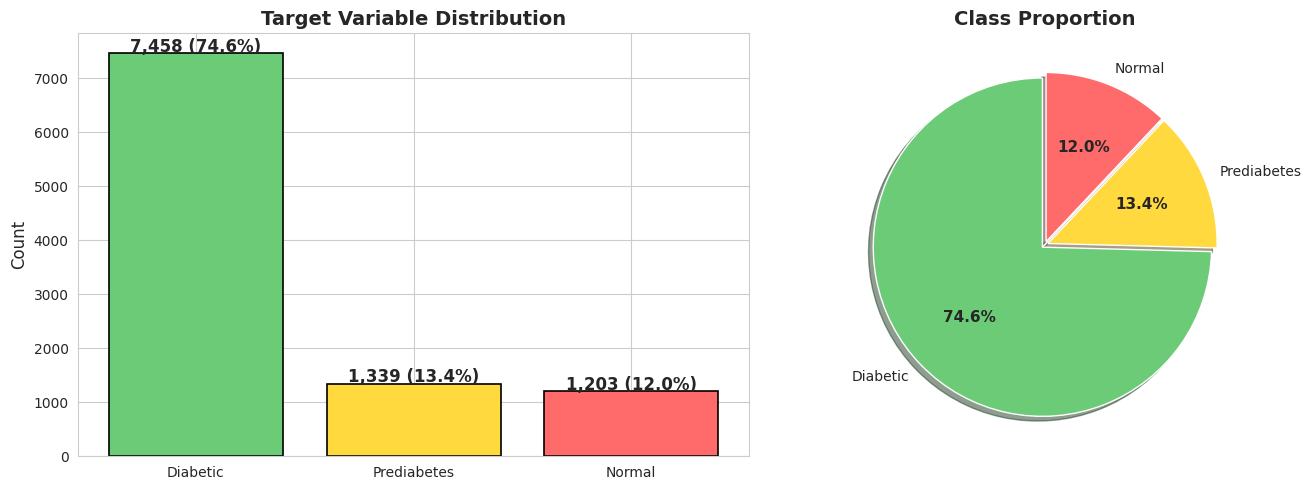

In [5]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#6BCB77', '#FFD93D', '#FF6B6B']
ax1 = axes[0]
counts = df['diabetes_status'].value_counts()
bars = ax1.bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=1.2)
for bar, count, pct in zip(bars, counts.values, (counts/len(df)*100).round(1)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{count:,} ({pct}%)', ha='center', fontweight='bold', fontsize=12)
ax1.set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12)

ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                                     colors=colors, explode=(0.02, 0.02, 0.02),
                                     shadow=True, startangle=90)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)
ax2.set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


In [6]:
print(f"   Majority (Diabetic): {counts['Diabetic']:,} ({counts['Diabetic']/len(df)*100:.1f}%)")
print(f"   Minority (Normal):   {counts['Normal']:,} ({counts['Normal']/len(df)*100:.1f}%)")
print(f"   Imbalance ratio:     {counts['Diabetic']/counts['Normal']:.1f}:1")

   Majority (Diabetic): 7,458 (74.6%)
   Minority (Normal):   1,203 (12.0%)
   Imbalance ratio:     6.2:1


### **4.2 Numeric Feature Distributions**

Numeric features (11): ['age', 'bmi', 'parity', 'years_since_diagnosis', 'fasting_glucose_mg_dl', 'hba1c_percent', 'total_cholesterol_mg_dl', 'ldl_mg_dl', 'hdl_mg_dl', 'triglycerides_mg_dl', 'creatinine_mg_dl']


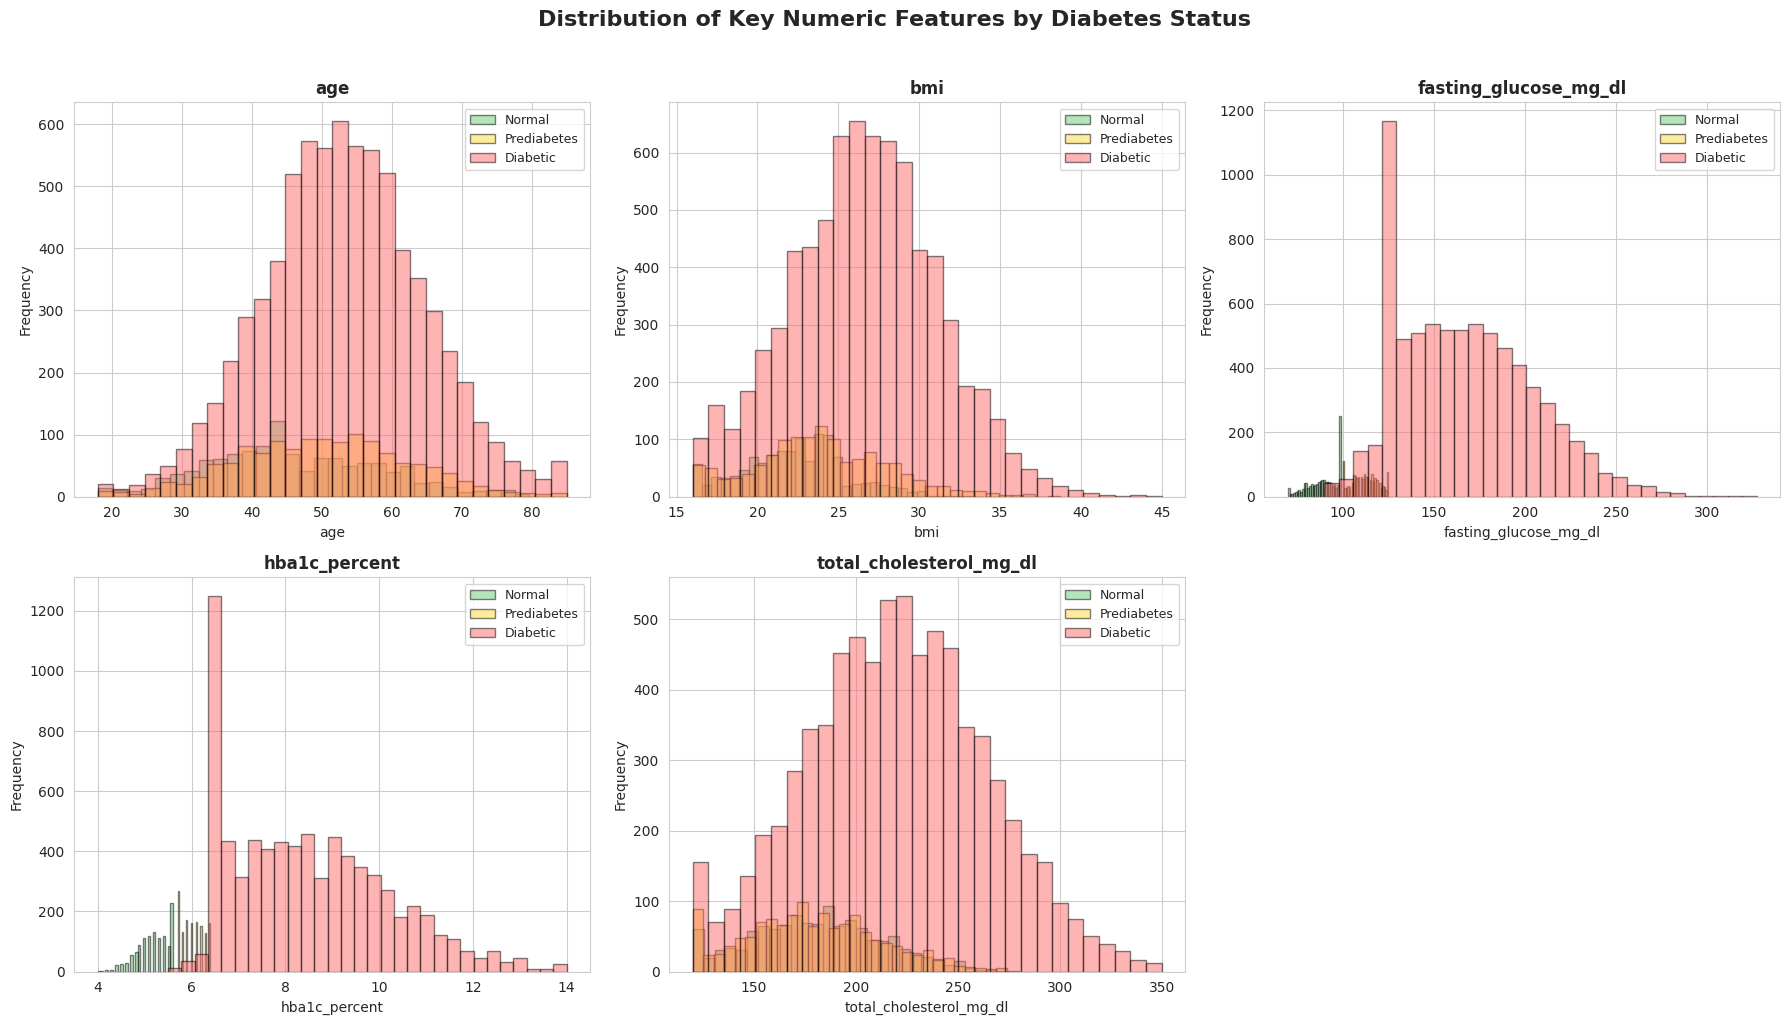

In [7]:
# Numeric columns
numeric_cols = df.select_dtypes(include=['float64']).columns.tolist()
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")

key_numeric = ['age', 'bmi', 'fasting_glucose_mg_dl', 'hba1c_percent', 'total_cholesterol_mg_dl']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_numeric):
    for status, color in zip(['Normal', 'Prediabetes', 'Diabetic'], ['#6BCB77', '#FFD93D', '#FF6B6B']):
        subset = df[df['diabetes_status'] == status][col].dropna()
        axes[i].hist(subset, bins=30, alpha=0.5, label=status, color=color, edgecolor='black')
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)

axes[5].set_visible(False)
plt.suptitle('Distribution of Key Numeric Features by Diabetes Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

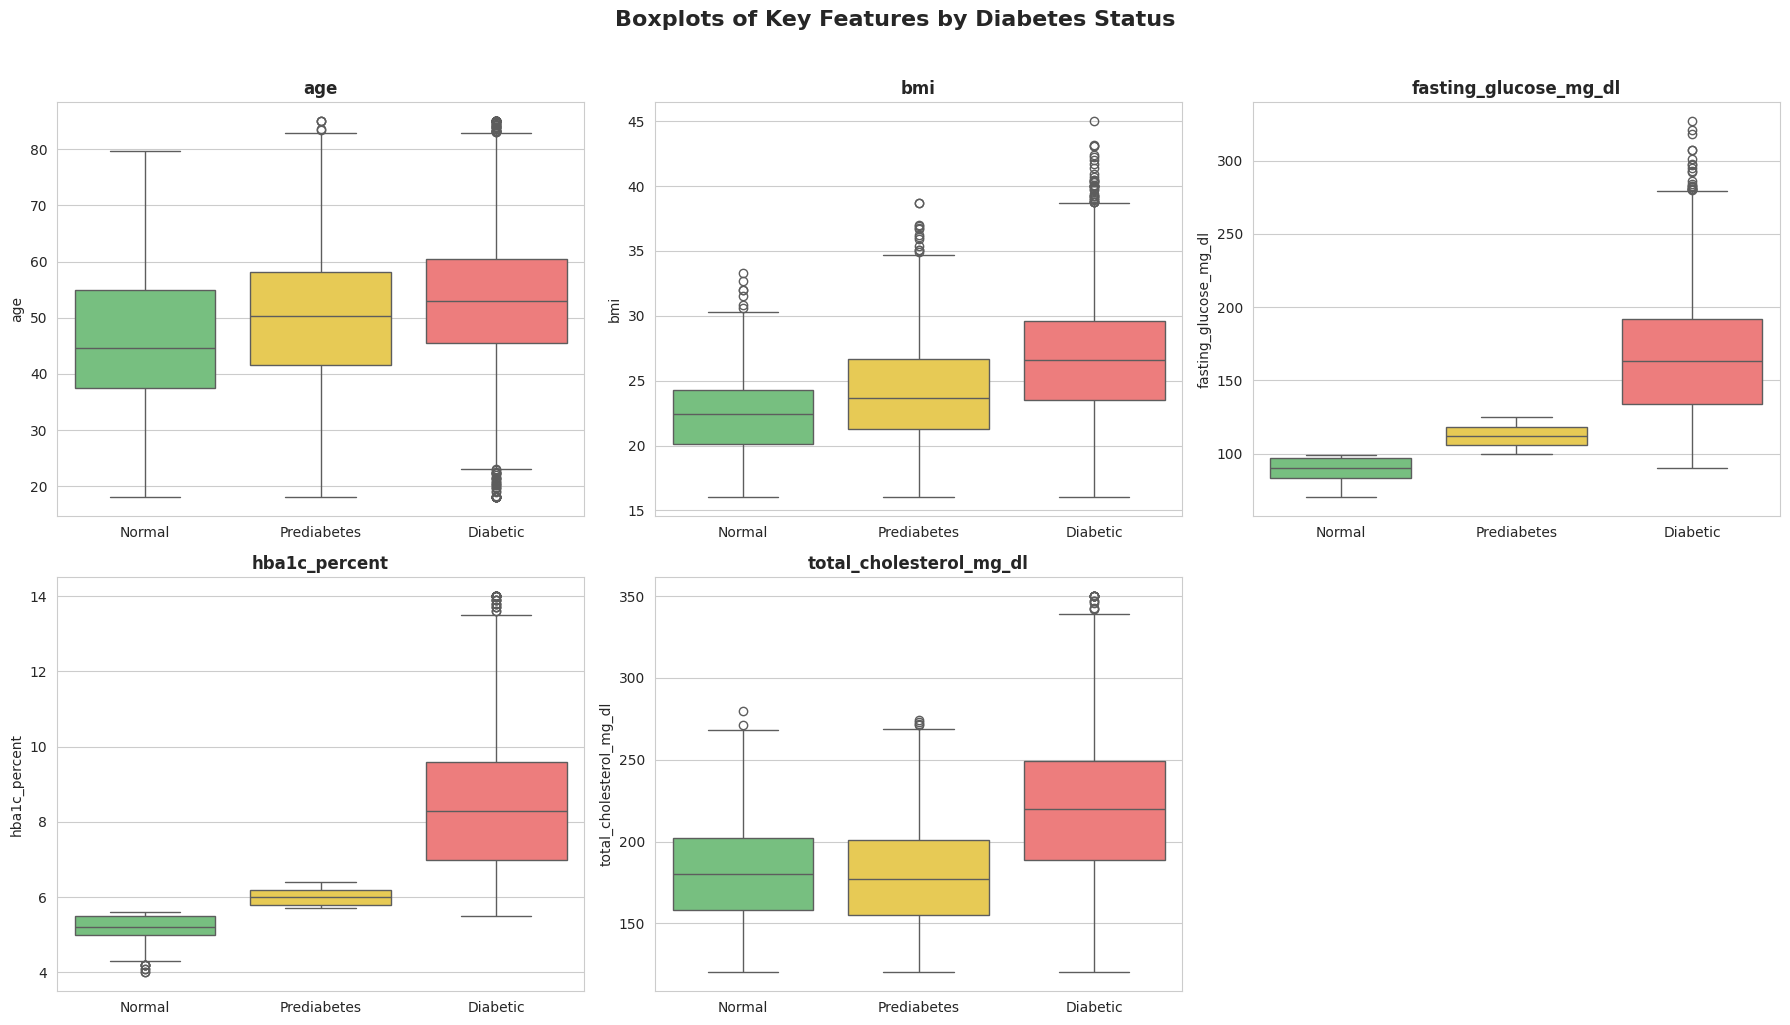

In [8]:
# Boxplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
palette = {'Normal': '#6BCB77', 'Prediabetes': '#FFD93D', 'Diabetic': '#FF6B6B'}

for i, col in enumerate(key_numeric):
    sns.boxplot(data=df, x='diabetes_status', y=col, palette=palette, ax=axes[i],
                order=['Normal', 'Prediabetes', 'Diabetic'])
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

axes[5].set_visible(False)
plt.suptitle('Boxplots of Key Features by Diabetes Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **4.3 Categorical Feature Distributions**

Categorical features (27)


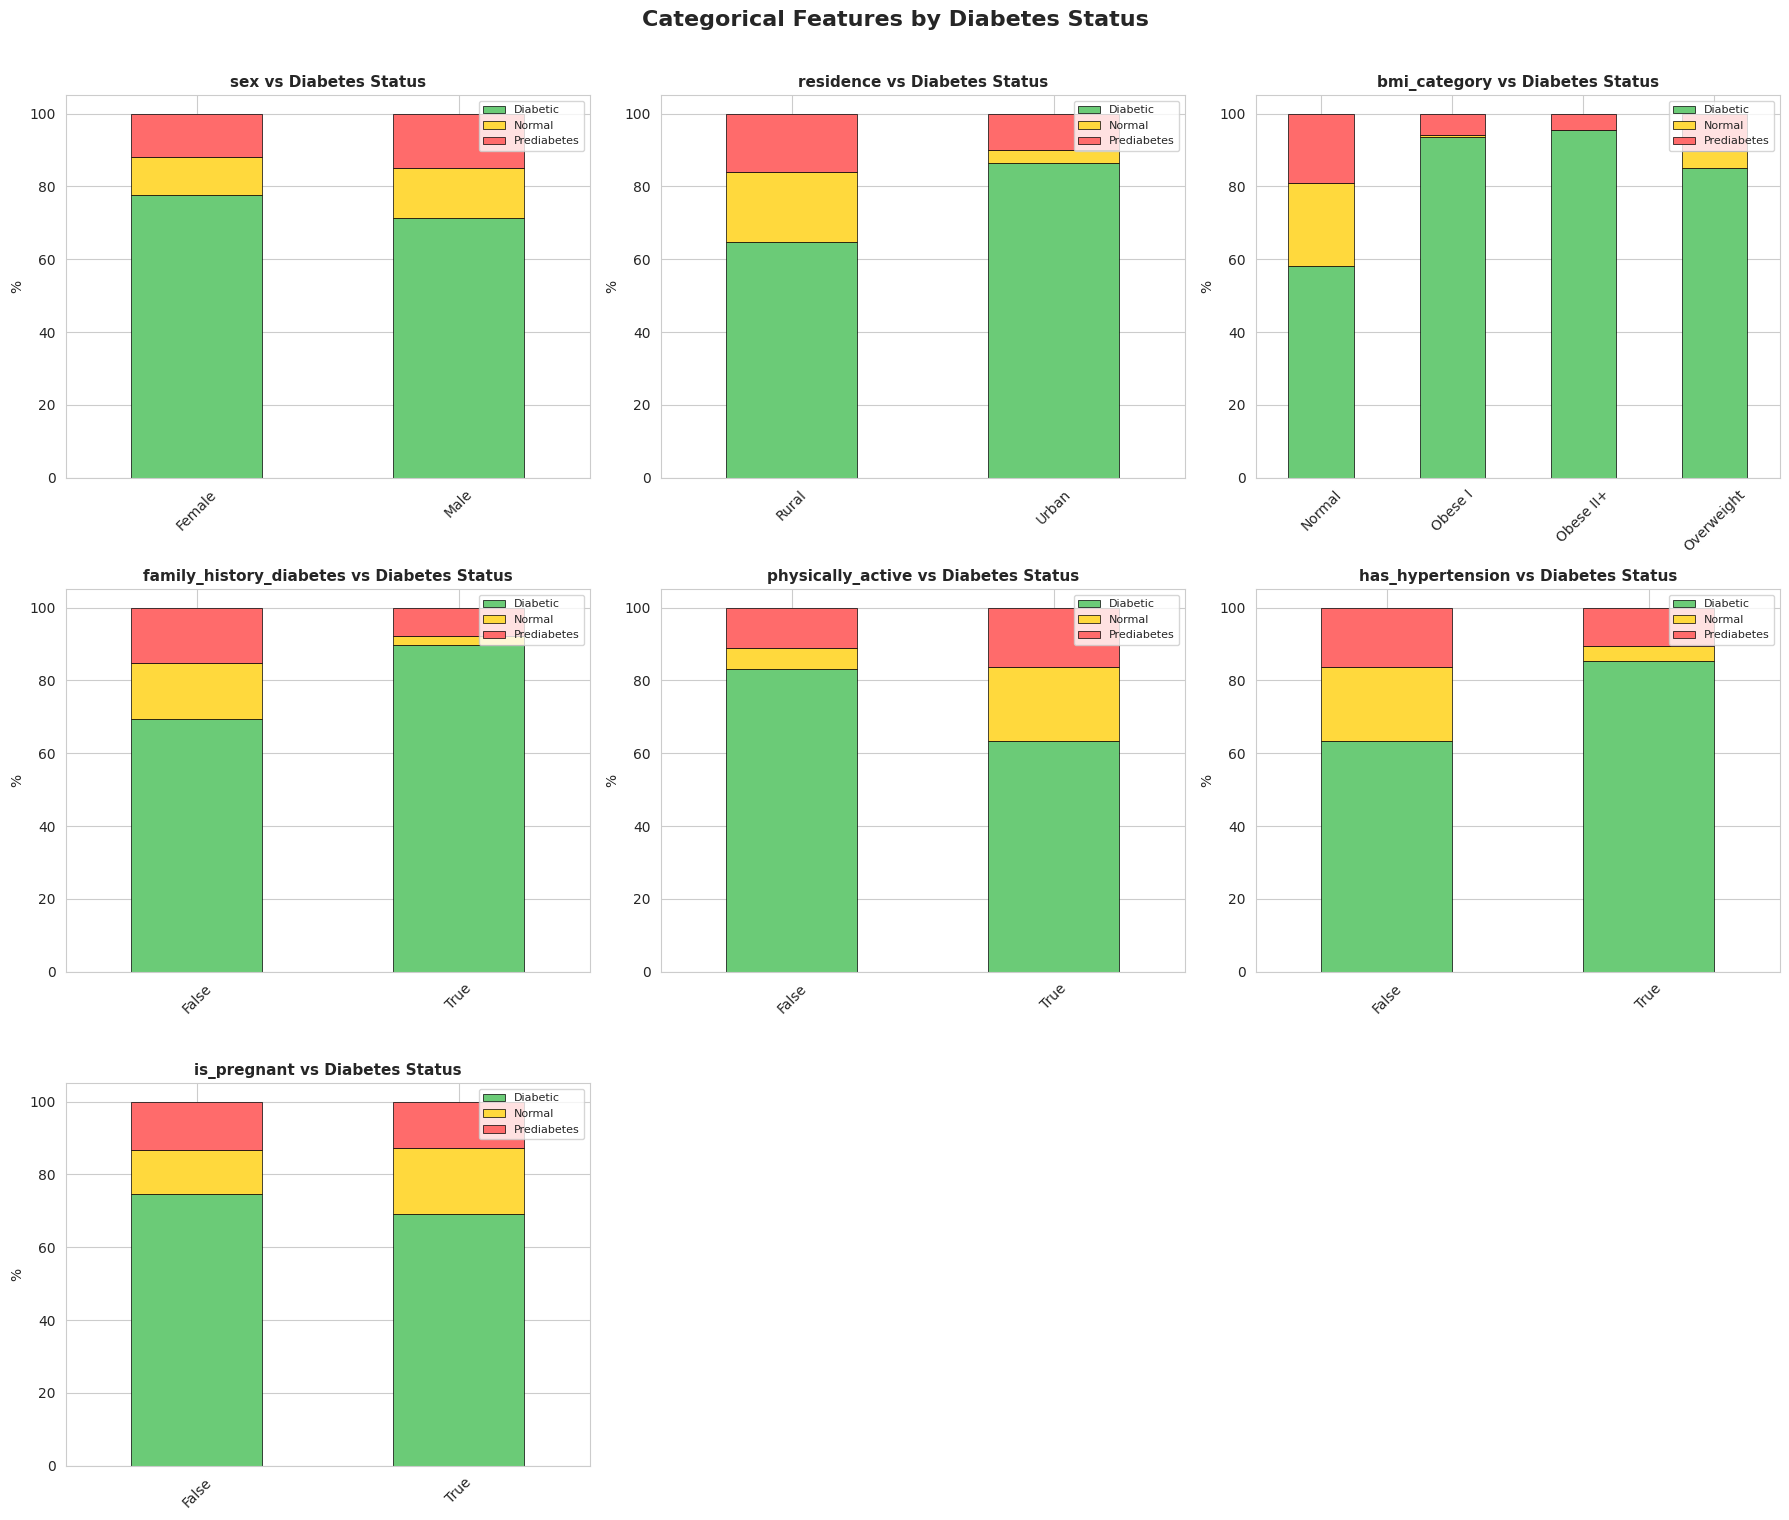

In [9]:
# Categorical columns
cat_cols_all = df.select_dtypes(include=['object', 'bool']).columns.tolist()
cat_cols_all = [c for c in cat_cols_all if c not in ['patient_id', 'diabetes_status']]
print(f"Categorical features ({len(cat_cols_all)})")

key_cat = ['sex', 'residence', 'bmi_category', 'family_history_diabetes',
           'physically_active', 'has_hypertension', 'is_pregnant']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(key_cat):
    ct = pd.crosstab(df[col], df['diabetes_status'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#6BCB77', '#FFD93D', '#FF6B6B'],
            edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'{col} vs Diabetes Status', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('%', fontsize=10)
    axes[i].legend(loc='upper right', fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(key_cat), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features by Diabetes Status', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### **4.4 Correlation Matrix**

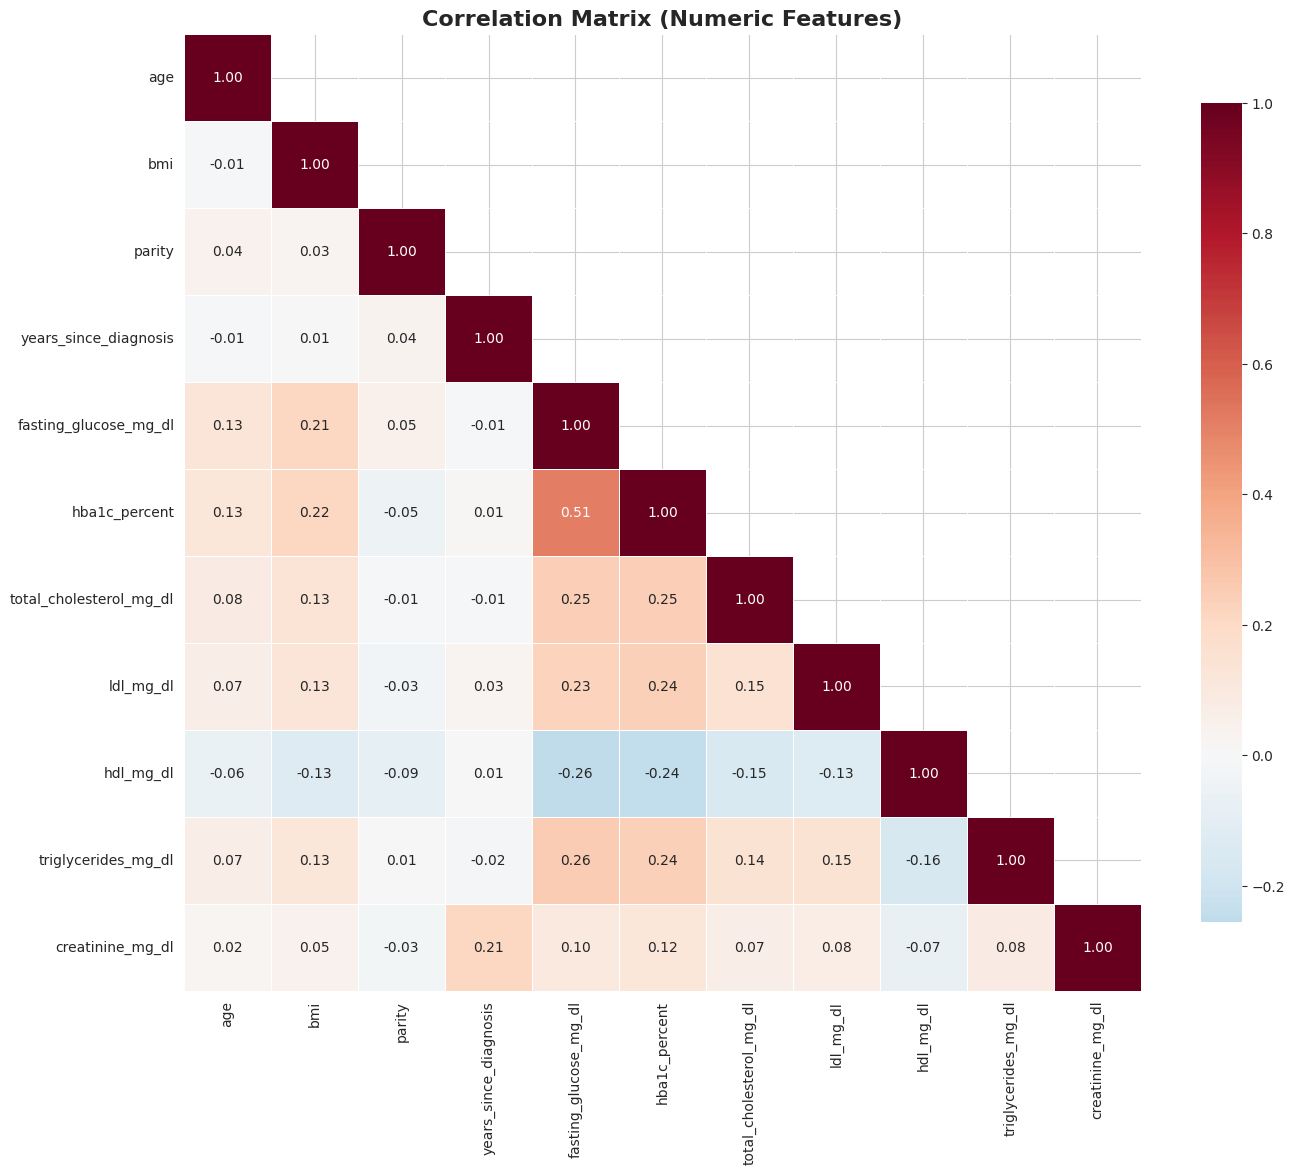

In [10]:
# Correlation heatmap
corr_df = df[numeric_cols].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix (Numeric Features)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## **5. Data Preprocessing**

### **5.1 Column Classification (Data Leakage Prevention)**

In [11]:
# CLASSIFY ALL COLUMNS BY ROLE
id_col = 'patient_id'
target_col = 'diabetes_status'
# Outcome-related columns
outcome_cols = [
    'diagnosed', 'years_since_diagnosis', 'on_medication',
    'medication_type', 'adherence',
    'retinopathy', 'nephropathy', 'neuropathy',
    'cardiovascular_disease', 'diabetic_foot_ulcer', 'microalbuminuria',
]
# Pregnancy columns
drop_pregnancy_cols = [
    'parity', 'preeclampsia', 'cesarean_delivery',
    'macrosomic_baby', 'neonatal_hypoglycemia', 'nicu_admission'
]
# Features to keep
feature_cols = [col for col in df.columns
               if col not in [id_col, target_col] + outcome_cols + drop_pregnancy_cols]
print(f"  ID (drop):        {id_col}")
print(f"  Target:            {target_col}")
print(f"  Outcome (drop):    {len(outcome_cols)}")
for c in outcome_cols:
    print(f"     - {c}")
print(f"  Pregnancy (drop):  {len(drop_pregnancy_cols)}")
for c in drop_pregnancy_cols:
    print(f"     - {c}")
print(f"  Features kept:     {len(feature_cols)}")
for c in feature_cols:
    print(f"     - {c}")

  ID (drop):        patient_id
  Target:            diabetes_status
  Outcome (drop):    11
     - diagnosed
     - years_since_diagnosis
     - on_medication
     - medication_type
     - adherence
     - retinopathy
     - nephropathy
     - neuropathy
     - cardiovascular_disease
     - diabetic_foot_ulcer
     - microalbuminuria
  Pregnancy (drop):  6
     - parity
     - preeclampsia
     - cesarean_delivery
     - macrosomic_baby
     - neonatal_hypoglycemia
     - nicu_admission
  Features kept:     21
     - age
     - sex
     - is_pregnant
     - residence
     - education
     - bmi
     - bmi_category
     - family_history_diabetes
     - previous_gdm
     - physically_active
     - has_hypertension
     - previous_macrosomia
     - pcos
     - hiv_positive
     - fasting_glucose_mg_dl
     - hba1c_percent
     - total_cholesterol_mg_dl
     - ldl_mg_dl
     - hdl_mg_dl
     - triglycerides_mg_dl
     - creatinine_mg_dl


### **5.2 Working DataFrame**

In [12]:
# Create working DataFrame
df_clean = df[feature_cols + [target_col]].copy()
print(f"Working DataFrame: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} cols")

missing_remaining = df_clean.isnull().sum()
missing_remaining = missing_remaining[missing_remaining > 0]
if len(missing_remaining) > 0:
    print(f"Missing values remaining: {len(missing_remaining)} columns")
    for col, count in missing_remaining.items():
        print(f"   - {col}: {count} ({count/len(df_clean)*100:.1f}%)")

Working DataFrame: 10,000 rows, 22 cols
Missing values remaining: 1 columns
   - education: 1985 (19.9%)


### **5.3 Handle Missing Values**

In [13]:
# Impute missing values
for col in df_clean.select_dtypes(include=['object']).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna('Unknown')
        print(f"   - {col}: filled with 'Unknown'")
for col in df_clean.select_dtypes(include=['bool']).columns:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f"   - {col}: filled with mode ({mode_val})")
for col in df_clean.select_dtypes(include=['float64']).columns:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"   - {col}: filled with median ({median_val:.2f})")
print(f"Missing after imputation: {df_clean.isnull().sum().sum()}")

   - education: filled with 'Unknown'
Missing after imputation: 0


### **5.4 Separate Features and Target**

In [14]:
# Separate X and y
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print(f"  {dict(zip(le_target.classes_, range(3)))}")
num_cols = X.select_dtypes(include=['float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
bool_cols = X.select_dtypes(include=['bool']).columns.tolist()
print(f"Numeric: {len(num_cols)} | Categorical: {len(cat_cols)} | Boolean: {len(bool_cols)}")

  {'Diabetic': 0, 'Normal': 1, 'Prediabetes': 2}
Numeric: 9 | Categorical: 4 | Boolean: 8


## **6. Train/Validation/Test Split**

In [15]:
# Stratified split (70/15/15) BEFORE encoding & SMOTENC
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)
numeric_fill_values = X_train_raw[num_cols].median()
print(f"  Train:      {X_train_raw.shape[0]:,} ({X_train_raw.shape[0]/len(X)*100:.0f}%)")
print(f"  Validation: {X_val_raw.shape[0]:,} ({X_val_raw.shape[0]/len(X)*100:.0f}%)")
print(f"  Test:       {X_test_raw.shape[0]:,} ({X_test_raw.shape[0]/len(X)*100:.0f}%)")
for label, count in zip(le_target.classes_, np.bincount(y_train)):
    print(f"  {label}: {count} ({count/len(y_train)*100:.1f}%)")

  Train:      7,000 (70%)
  Validation: 1,500 (15%)
  Test:       1,500 (15%)
  Diabetic: 5221 (74.6%)
  Normal: 842 (12.0%)
  Prediabetes: 937 (13.4%)


## **7. Feature Encoding and SMOTENC**

In [16]:
# STEP 1: Label Encoding for SMOTENC compatibility
def manual_encode(df_in, cat_cols, bool_cols, encoders=None):
    """Encode categorical and boolean columns using training encoders."""
    df_enc = df_in.copy()
    if encoders is None:
        encoders = {}
    for col in cat_cols:
        if col not in encoders:
            encoders[col] = LabelEncoder().fit(df_enc[col].astype(str))
        encoder = encoders[col]
        mapping = {label: index for index, label in enumerate(encoder.classes_)}
        # Encode unseen inference categories as -1; OneHotEncoder will ignore them.
        df_enc[col] = df_enc[col].astype(str).map(mapping).fillna(-1).astype(int)
    for col in bool_cols:
        df_enc[col] = df_enc[col].astype(int)
    return df_enc, encoders
X_train_enc, cat_encoders = manual_encode(X_train_raw, cat_cols, bool_cols)
X_val_enc, _ = manual_encode(X_val_raw, cat_cols, bool_cols, cat_encoders)
X_test_enc, _ = manual_encode(X_test_raw, cat_cols, bool_cols, cat_encoders)
print(f"Training set (label-encoded): {X_train_enc.shape}")


Training set (label-encoded): (7000, 21)


In [17]:
# STEP 2: Apply SMOTENC to training data only
print(f"Before: {Counter(y_train)}")
categorical_indices = [X_train_enc.columns.get_loc(col) for col in cat_cols + bool_cols]
smote = SMOTENC(categorical_features=categorical_indices, random_state=42, k_neighbors=5)
X_train_smote_enc, y_train_smote = smote.fit_resample(X_train_enc, y_train)
X_train_smote_enc = pd.DataFrame(X_train_smote_enc, columns=X_train_enc.columns)
print(f"After:  {Counter(y_train_smote)}")
print(f"Synthetic samples added: {X_train_smote_enc.shape[0] - X_train_enc.shape[0]:,}")

Before: Counter({np.int64(0): 5221, np.int64(2): 937, np.int64(1): 842})
After:  Counter({np.int64(0): 5221, np.int64(1): 5221, np.int64(2): 5221})
Synthetic samples added: 8,663


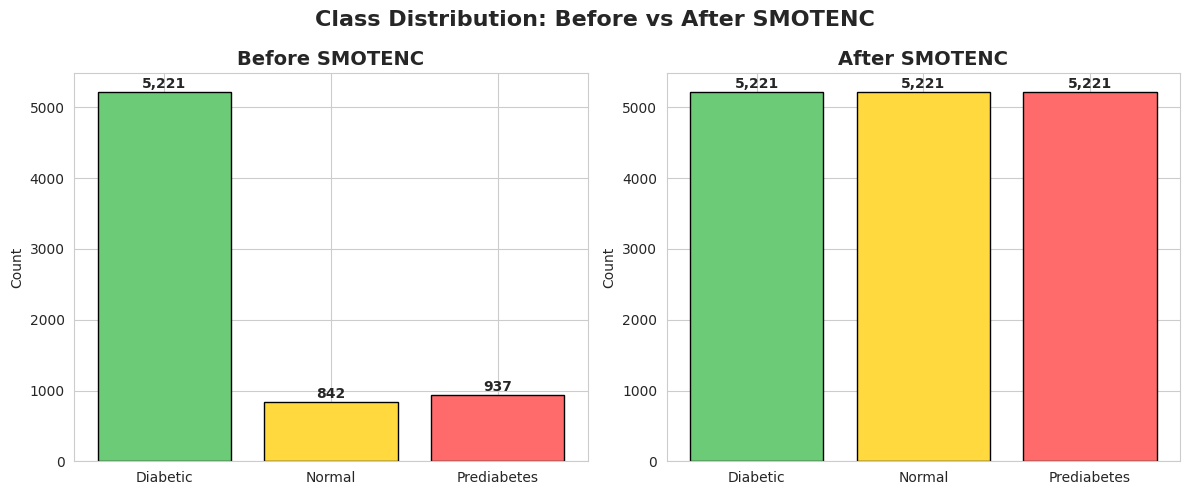

In [18]:
# Visualize before/after SMOTENC
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = le_target.classes_

before_counts = [Counter(y_train)[i] for i in range(3)]
axes[0].bar(labels, before_counts, color=['#6BCB77', '#FFD93D', '#FF6B6B'], edgecolor='black')
for i, (label, count) in enumerate(zip(labels, before_counts)):
    axes[0].text(i, count + 50, f'{count:,}', ha='center', fontweight='bold')
axes[0].set_title('Before SMOTENC', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

after_counts = [Counter(y_train_smote)[i] for i in range(3)]
axes[1].bar(labels, after_counts, color=['#6BCB77', '#FFD93D', '#FF6B6B'], edgecolor='black')
for i, (label, count) in enumerate(zip(labels, after_counts)):
    axes[1].text(i, count + 50, f'{count:,}', ha='center', fontweight='bold')
axes[1].set_title('After SMOTENC', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('Class Distribution: Before vs After SMOTENC', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# STEP 3: StandardScaler + OneHotEncoder AFTER SMOTENC
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols),
    ('bool', 'passthrough', bool_cols)
])
X_train_smote = preprocessor.fit_transform(X_train_smote_enc)
X_val = preprocessor.transform(X_val_enc)
X_test = preprocessor.transform(X_test_enc)
cat_encoded_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_encoded_names) + bool_cols
print(f"  X_train_smote: {X_train_smote.shape}")
print(f"  X_val:         {X_val.shape}")
print(f"  X_test:        {X_test.shape}")
print(f"  Total features: {len(all_feature_names)}")

  X_train_smote: (15663, 25)
  X_val:         (1500, 25)
  X_test:        (1500, 25)
  Total features: 25


### **7.1 One-Hot Encode Target**

In [20]:
# One-hot encode target for deep learning
y_train_cat = to_categorical(y_train_smote, num_classes=3)
y_val_cat = to_categorical(y_val, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)
print(f"Input dim: {X_train_smote.shape[1]}, Output dim: 3")


Input dim: 25, Output dim: 3


## **8. Deep Learning Models**

### **8.1 ANN (Artificial Neural Network)**

In [21]:
input_dim = X_train_smote.shape[1]

def build_ann(input_dim, num_classes=3, dropout_rate=0.3):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate * 0.67),
        Dense(num_classes, activation='softmax')
    ])
    return model

ann_model = build_ann(input_dim)
ann_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,907 (202.76 KB)

 Trainable params: 50,947 (199.01 KB)

 Non-trainable params: 960 (3.75 KB)

In [22]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)
history_ann = ann_model.fit(
    X_train_smote, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=100, batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8919 - loss: 0.5704 - val_accuracy: 0.9340 - val_loss: 0.4430 - learning_rate: 0.0010
Epoch 2/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9701 - loss: 0.3433 - val_accuracy: 0.9860 - val_loss: 0.2766 - learning_rate: 0.0010
Epoch 3/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9784 - loss: 0.2793 - val_accuracy: 0.9873 - val_loss: 0.2314 - learning_rate: 0.0010
Epoch 4/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9789 - loss: 0.2378 - val_accuracy: 0.9900 - val_loss: 0.1916 - learning_rate: 0.0010
Epoch 5/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9833 - loss: 0.1955 - val_accuracy: 0.9867 - val_loss: 0.1730 - learning_rate: 0.0010
Epoch 6/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9805 - loss: 0.1765 - val_accuracy: 0.9900 - val_loss: 0.1352 - learning_rate: 0.0010
Epoch 7/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9847 - loss: 0

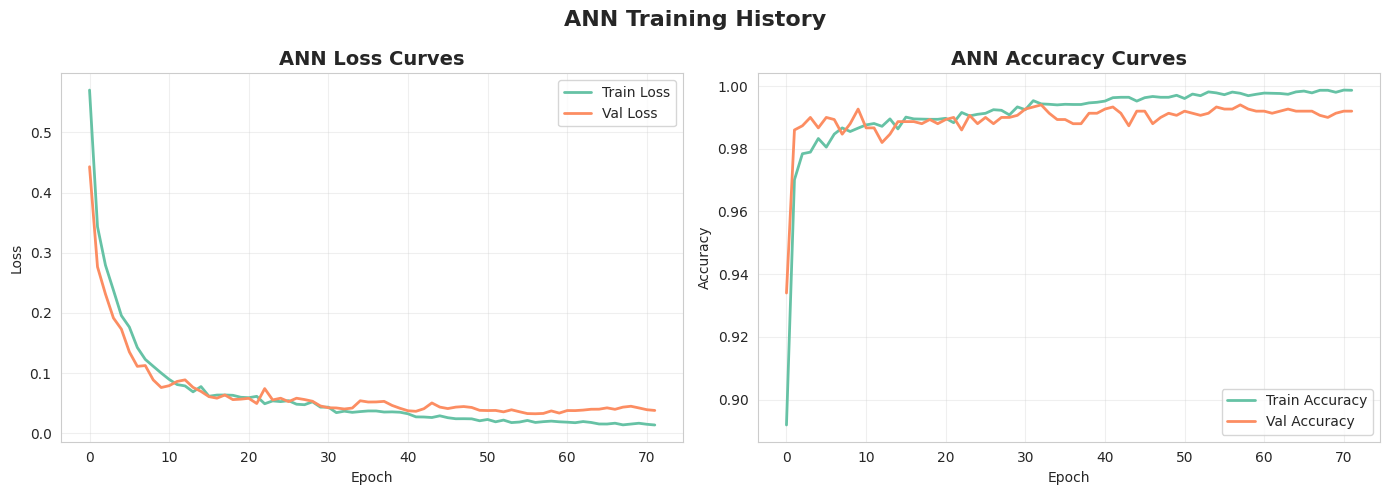

In [23]:
# ANN training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_ann.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_ann.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('ANN Loss Curves', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_ann.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history_ann.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_title('ANN Accuracy Curves', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('ANN Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **8.2 DNN (Deep Neural Network)**

In [24]:
def build_dnn(input_dim, num_classes=3, dropout_rate=0.35):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate * 0.7),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate * 0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

dnn_model = build_dnn(input_dim)
dnn_model.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
dnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │        13,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,755 (1010.76 KB)

 Trainable params: 256,259 (1001.01 KB)

 Non-trainable params: 2,496 (9.75 KB)

In [25]:
early_stop_dnn = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
reduce_lr_dnn = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
history_dnn = dnn_model.fit(
    X_train_smote, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=150, batch_size=64,
    callbacks=[early_stop_dnn, reduce_lr_dnn],
    verbose=1
)


Epoch 1/150
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7649 - loss: 1.4614 - val_accuracy: 0.6507 - val_loss: 1.8006 - learning_rate: 5.0000e-04
Epoch 2/150
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9490 - loss: 1.0133 - val_accuracy: 0.9640 - val_loss: 0.9467 - learning_rate: 5.0000e-04
Epoch 3/150
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9640 - loss: 0.9213 - val_accuracy: 0.9840 - val_loss: 0.8400 - learning_rate: 5.0000e-04
Epoch 4/150
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9705 - loss: 0.8488 - val_accuracy: 0.9847 - val_loss: 0.7784 - learning_rate: 5.0000e-04
Epoch 5/150
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9741 - loss: 0.7822 - val_accuracy: 0.9807 - val_loss: 0.7254 - learning_rate: 5.0000e-04
Epoch 6/150
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9770 - loss: 0.7064 - val_accuracy: 0.9847 - val_loss: 0.6418 - learning_rate: 5.0000e-04
Epoch 7/150
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - ac

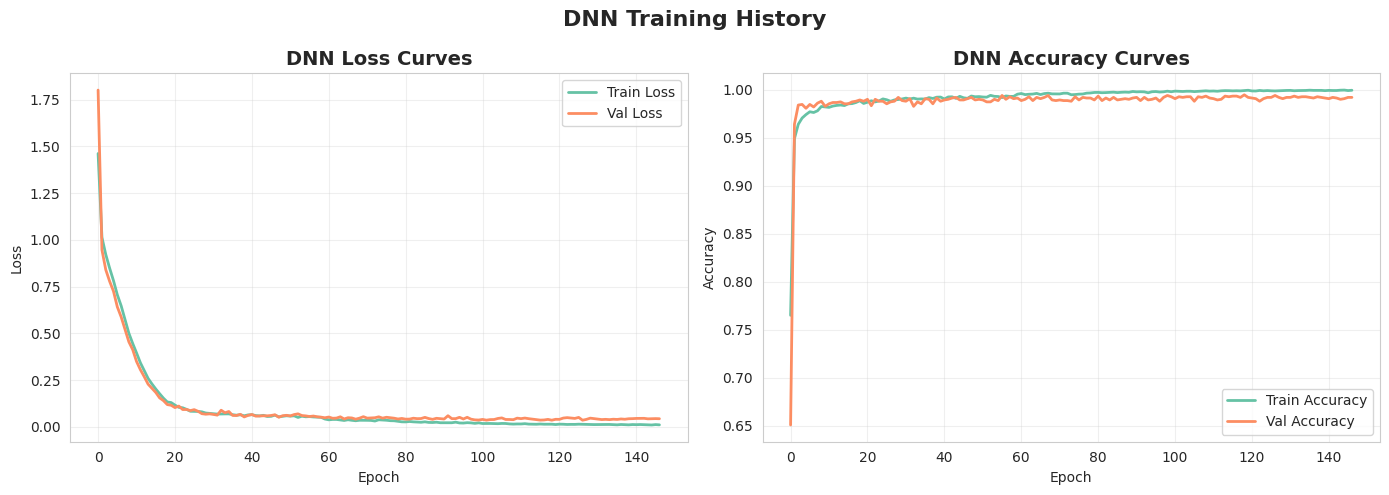

In [26]:
# DNN training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_dnn.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_dnn.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('DNN Loss Curves', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_dnn.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history_dnn.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_title('DNN Accuracy Curves', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('DNN Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## **9. Model Evaluation**

In [27]:
def evaluate_model(model, X_data, y_true, y_true_cat, model_name):
    y_pred_proba = model.predict(X_data, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    auc_ovr = roc_auc_score(y_true_cat, y_pred_proba, multi_class='ovr', average='weighted')
    print()
    print(f"{model_name} Test Performance")
    print()
    print(f"  Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUC-ROC:   {auc_ovr:.4f}")
    print(classification_report(y_true, y_pred, target_names=le_target.classes_))
    return y_pred, y_pred_proba, (acc, prec, rec, f1, auc_ovr)
y_pred_ann, y_proba_ann, metrics_ann = evaluate_model(ann_model, X_test, y_test, y_test_cat, 'ANN')
y_pred_dnn, y_proba_dnn, metrics_dnn = evaluate_model(dnn_model, X_test, y_test, y_test_cat, 'DNN')


ANN Test Performance

  Accuracy:  0.9873 (98.73%)
  Precision: 0.9873
  Recall:    0.9873
  F1-Score:  0.9873
  AUC-ROC:   0.9996
              precision    recall  f1-score   support

    Diabetic       0.99      0.99      0.99      1119
      Normal       0.98      1.00      0.99       180
 Prediabetes       0.96      0.95      0.95       201

    accuracy                           0.99      1500
   macro avg       0.98      0.98      0.98      1500
weighted avg       0.99      0.99      0.99      1500


DNN Test Performance

  Accuracy:  0.9887 (98.87%)
  Precision: 0.9887
  Recall:    0.9887
  F1-Score:  0.9887
  AUC-ROC:   0.9996
              precision    recall  f1-score   support

    Diabetic       0.99      0.99      0.99      1119
      Normal       0.99      1.00      0.99       180
 Prediabetes       0.96      0.96      0.96       201

    accuracy                           0.99      1500
   macro avg       0.98      0.98      0.98      1500
weighted avg       0.99      

### **9.1 Confusion Matrices**

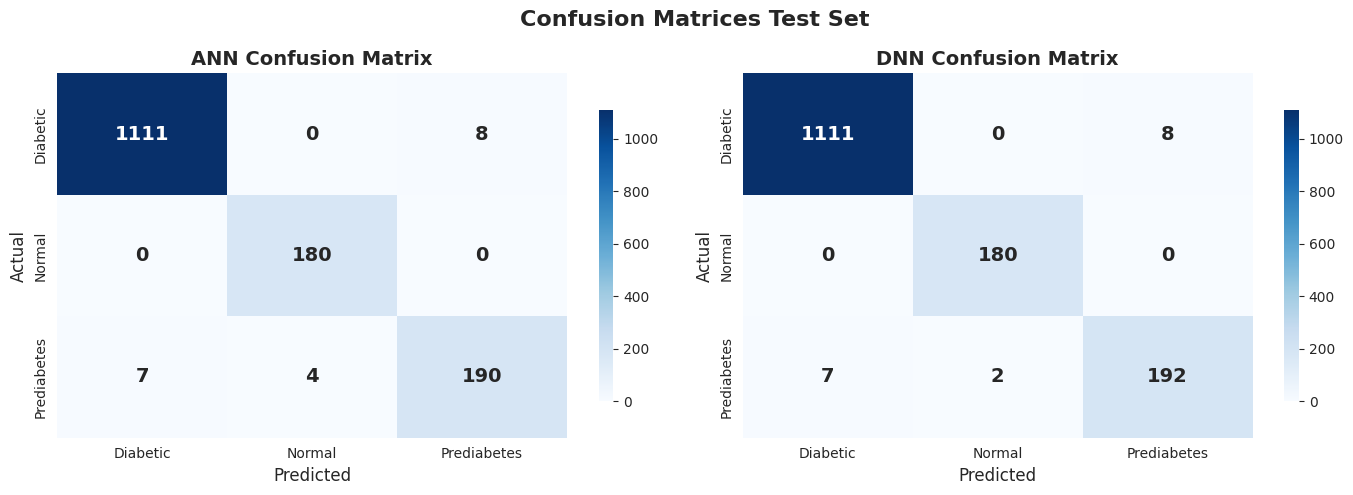

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, model_name in zip(axes, [y_pred_ann, y_pred_dnn], ['ANN', 'DNN']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le_target.classes_, yticklabels=le_target.classes_,
                cbar_kws={'shrink': 0.8}, annot_kws={'fontsize': 14, 'fontweight': 'bold'})
    ax.set_title(f'{model_name} Confusion Matrix', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)

plt.suptitle('Confusion Matrices Test Set', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **9.2 ROC Curves**

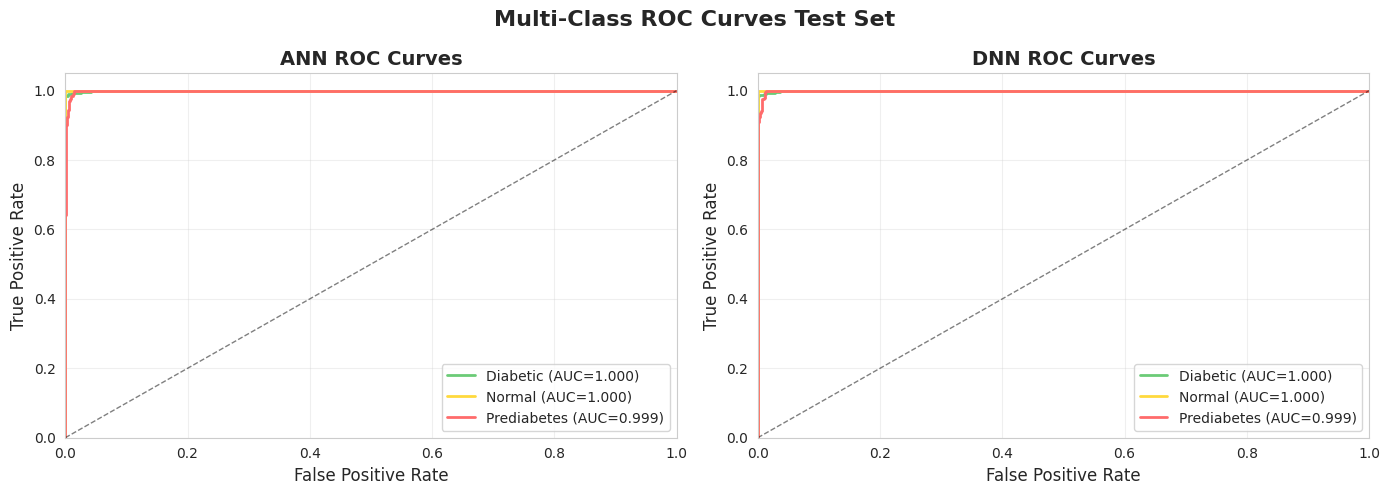

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_roc = ['#6BCB77', '#FFD93D', '#FF6B6B']

for ax, y_proba, model_name in zip(axes, [y_proba_ann, y_proba_dnn], ['ANN', 'DNN']):
    for i, (class_name, color) in enumerate(zip(le_target.classes_, colors_roc)):
        fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{class_name} (AUC={roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'{model_name} ROC Curves', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Multi-Class ROC Curves Test Set', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **9.3 Model Comparison**

In [30]:
comparison_df = pd.DataFrame({
    'Model': ['ANN', 'DNN'],
    'Accuracy': [metrics_ann[0], metrics_dnn[0]],
    'Precision': [metrics_ann[1], metrics_dnn[1]],
    'Recall': [metrics_ann[2], metrics_dnn[2]],
    'F1-Score': [metrics_ann[3], metrics_dnn[3]],
    'AUC-ROC': [metrics_ann[4], metrics_dnn[4]]
})
print(comparison_df.style.background_gradient(
    cmap='Greens', subset=['Accuracy', 'F1-Score', 'AUC-ROC']
).format({col: '{:.4f}' for col in comparison_df.columns if col != 'Model'}))
best_idx = np.argmax([metrics_ann[3], metrics_dnn[3]])
best_model_name = ['ANN', 'DNN'][best_idx]
best_model = [ann_model, dnn_model][best_idx]
best_pred_proba = [y_proba_ann, y_proba_dnn][best_idx]
print(f"\nBest model (by F1-Score): {best_model_name}")


Best model (by F1-Score): DNN


## **10. SHAP (XGBoost)**

### **10.1 XGBoost Model**

In [31]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='mlogloss'
)
xgb_model.fit(X_train_smote, y_train_smote)
xgb_pred = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred, average='weighted')
print(f"XGBoost Accuracy: {xgb_acc:.4f}")
print(f"XGBoost F1-Score:  {xgb_f1:.4f}")
print(classification_report(y_test, xgb_pred, target_names=le_target.classes_))

XGBoost Accuracy: 0.9973
XGBoost F1-Score:  0.9973
              precision    recall  f1-score   support

    Diabetic       1.00      1.00      1.00      1119
      Normal       1.00      1.00      1.00       180
 Prediabetes       0.98      1.00      0.99       201

    accuracy                           1.00      1500
   macro avg       0.99      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



### **10.2 SHAP Global Feature Importance**

In [32]:
# LabelEncoder sorts alphabetically: Diabetic=0, Normal=1, Prediabetes=2
# Normalize SHAP outputs to (samples, features, classes) across SHAP versions.
def _as_shap_array(raw_values, n_samples, n_features):
    values = raw_values.values if hasattr(raw_values, 'values') else raw_values
    if isinstance(values, list):
        values = np.stack([np.asarray(item) for item in values], axis=-1)
    else:
        values = np.asarray(values)
    if values.ndim == 2:
        if values.shape != (n_samples, n_features):
            raise ValueError(f"Unexpected SHAP shape: {values.shape}")
        values = values[:, :, np.newaxis]
    elif values.ndim == 3:
        if values.shape[0] == n_samples and values.shape[1] == n_features:
            pass
        elif values.shape[0] == n_samples and values.shape[2] == n_features:
            values = np.transpose(values, (0, 2, 1))
        elif values.shape[1] == n_samples and values.shape[2] == n_features:
            values = np.transpose(values, (1, 2, 0))
        else:
            raise ValueError(f"Unexpected SHAP shape: {values.shape}")
    else:
        raise ValueError(f"Unexpected SHAP dimensions: {values.ndim}")
    return values

def _shap_base_value(expected_value, class_index):
    values = np.asarray(expected_value).reshape(-1)
    return float(values[0] if values.size == 1 else values[class_index])

shap_sample_size = min(500, X_test.shape[0])
X_shap = X_test[:shap_sample_size]

explainer_xgb = shap.TreeExplainer(xgb_model)
raw_shap_values_xgb = explainer_xgb.shap_values(X_shap)
shap_values_xgb = _as_shap_array(raw_shap_values_xgb, X_shap.shape[0], X_shap.shape[1])
print(f"SHAP values computed: {shap_values_xgb.shape}")

SHAP values computed: (500, 25, 3)


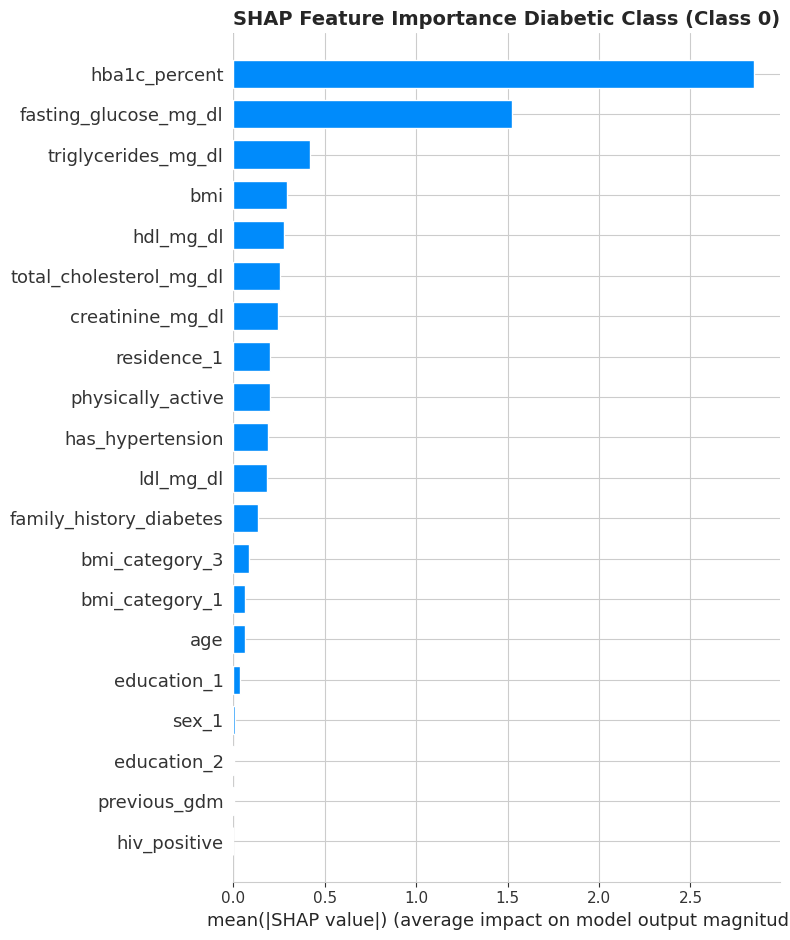

In [33]:
# SHAP bar plot (index 0 = Diabetic)
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values_xgb[:, :, 0], X_shap,
    feature_names=all_feature_names,
    plot_type='bar', max_display=20, show=False
)
plt.title('SHAP Feature Importance Diabetic Class (Class 0)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

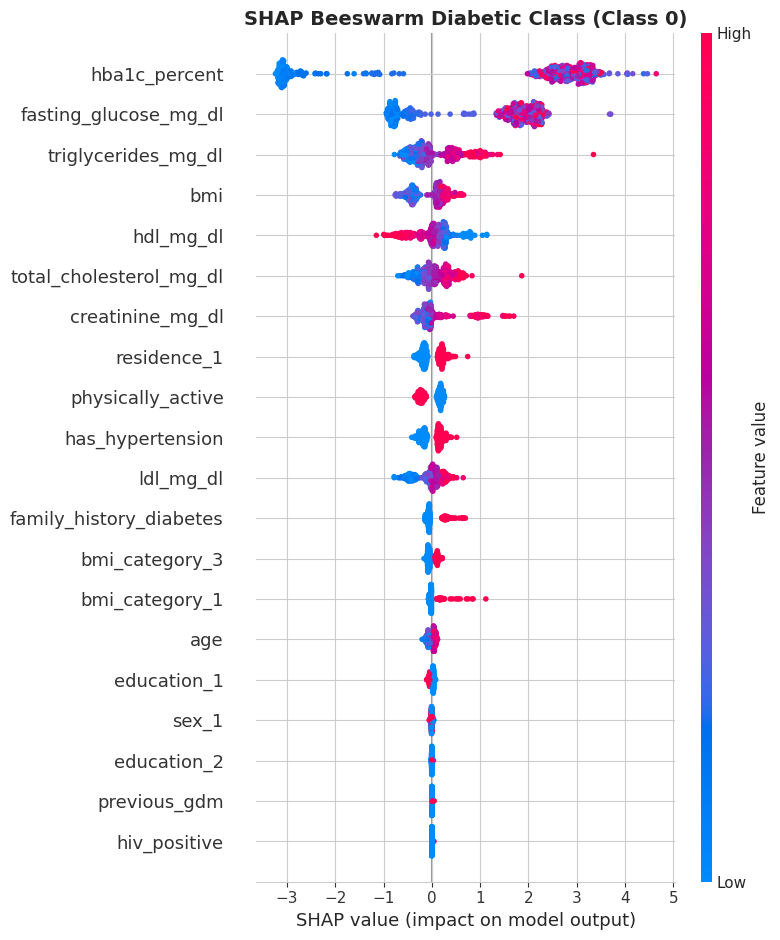

In [34]:
# SHAP beeswarm (index 0 = Diabetic)
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values_xgb[:, :, 0], X_shap,
    feature_names=all_feature_names, max_display=20, show=False
)
plt.title('SHAP Beeswarm Diabetic Class (Class 0)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### **10.3 SHAP Local Explanation**

  Actual:    Diabetic
  Predicted: Diabetic


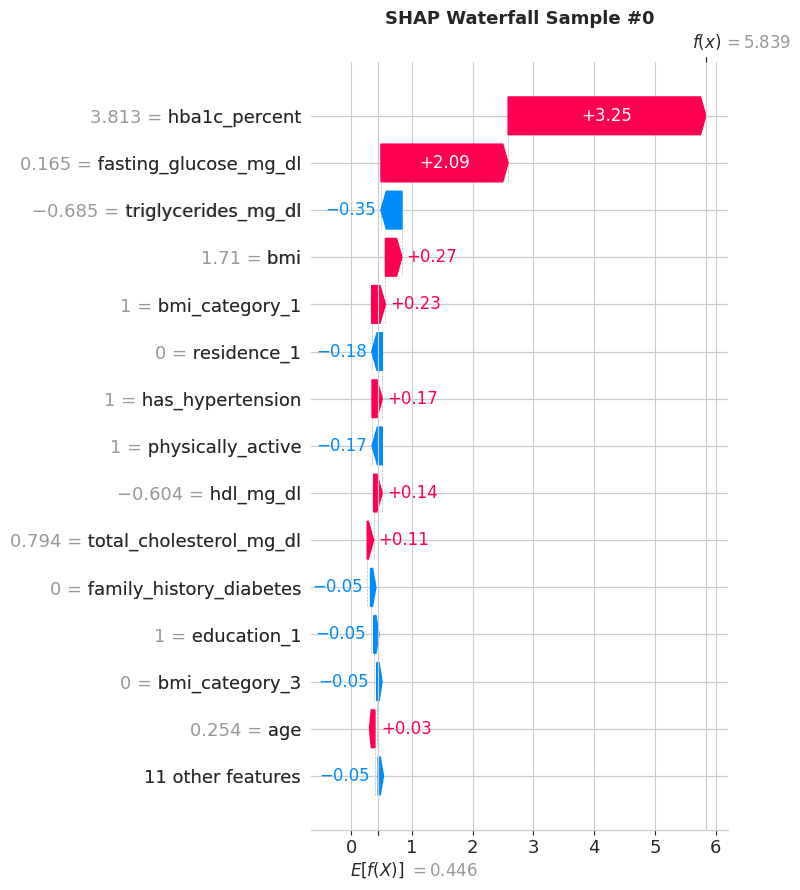

In [35]:
sample_idx = 0
print(f"  Actual:    {le_target.classes_[y_test[sample_idx]]}")
print(f"  Predicted: {le_target.classes_[xgb_pred[sample_idx]]}")
plt.figure(figsize=(12, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_xgb[sample_idx, :, xgb_pred[sample_idx]],
        base_values=_shap_base_value(explainer_xgb.expected_value, xgb_pred[sample_idx]),
        data=X_shap[sample_idx],
        feature_names=all_feature_names
    ),
    max_display=15, show=False
)
plt.title(f'SHAP Waterfall Sample #{sample_idx}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

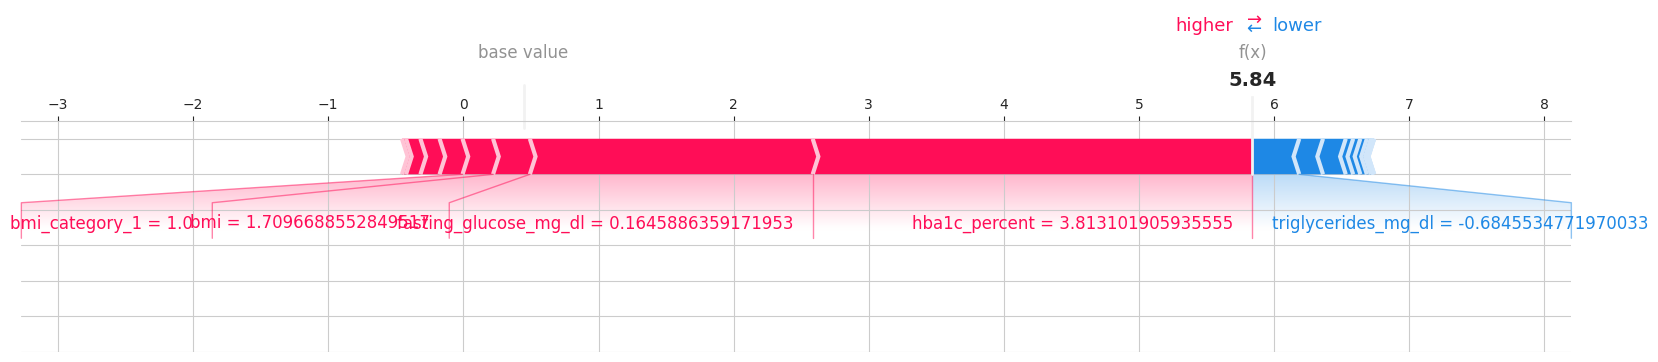

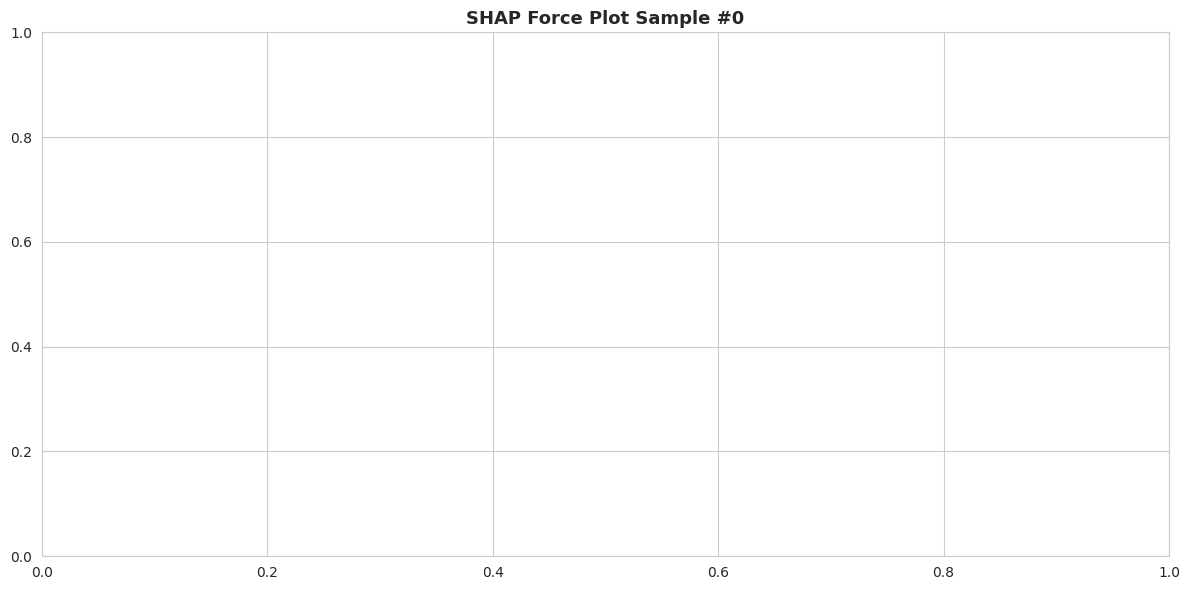

In [36]:
# SHAP force plot
shap.force_plot(
    _shap_base_value(explainer_xgb.expected_value, xgb_pred[sample_idx]),
    shap_values_xgb[sample_idx, :, xgb_pred[sample_idx]],
    X_shap[sample_idx],
    feature_names=all_feature_names,
    matplotlib=True
)
plt.title(f'SHAP Force Plot Sample #{sample_idx}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## **11. LIME (Deep Learning Model)**

### **11.1 LIME Setup**

In [37]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_smote,
    feature_names=all_feature_names,
    class_names=list(le_target.classes_),
    mode='classification',
    random_state=42
)
def dl_predict_proba(x):
    return best_model.predict(x, verbose=0)

### **11.2 LIME Local Explanation**

  Actual: Diabetic
  Predicted: Diabetic


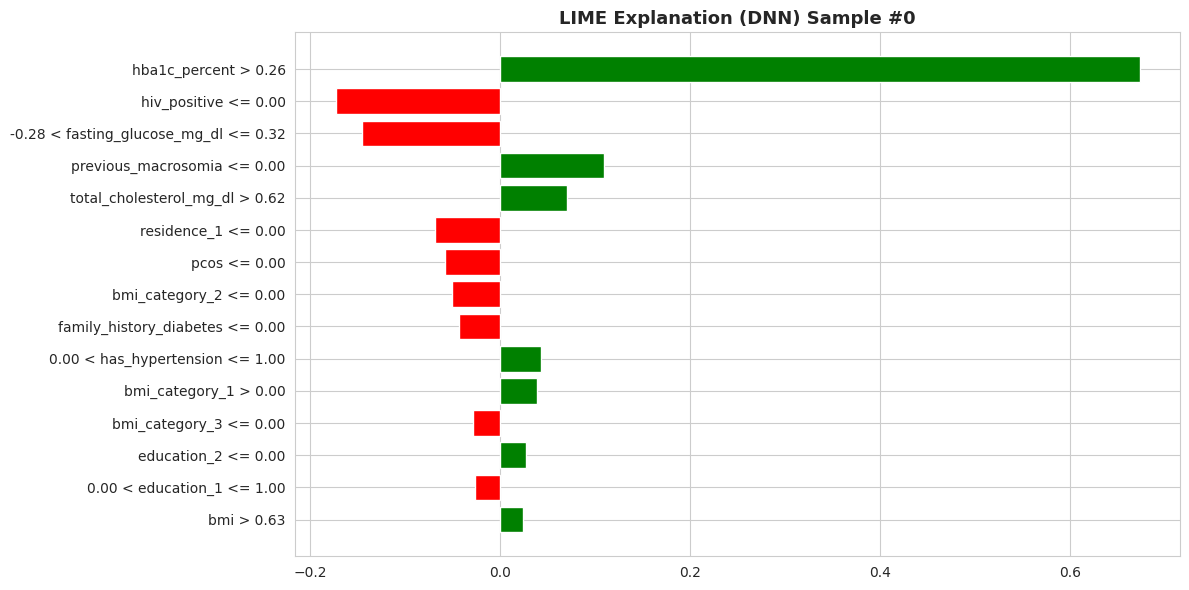

In [38]:
lime_sample_idx = 0
print(f"  Actual: {le_target.classes_[y_test[lime_sample_idx]]}")
lime_exp = lime_explainer.explain_instance(
    X_test[lime_sample_idx], dl_predict_proba, num_features=15, top_labels=3
)
predicted_class = np.argmax(dl_predict_proba(X_test[lime_sample_idx:lime_sample_idx+1])[0])
print(f"  Predicted: {le_target.classes_[predicted_class]}")
fig = lime_exp.as_pyplot_figure(label=predicted_class)
plt.title(f'LIME Explanation ({best_model_name}) Sample #{lime_sample_idx}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

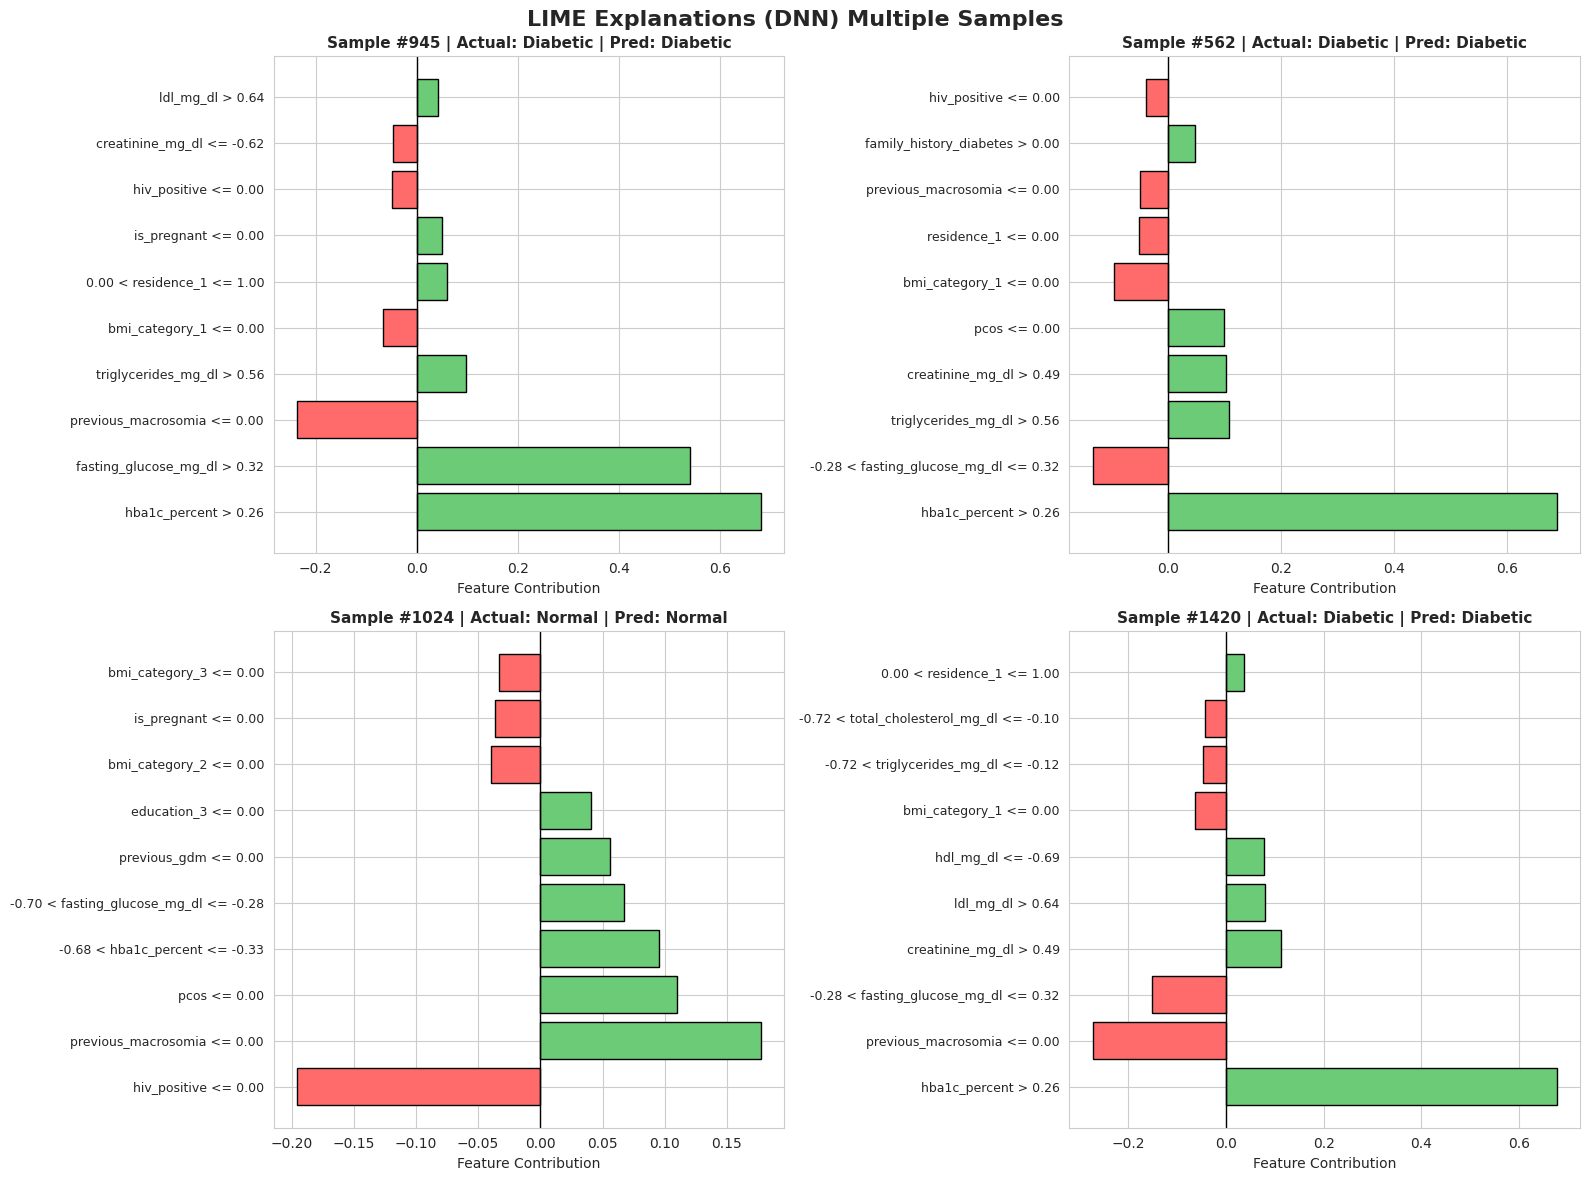

In [39]:
# Multiple LIME explanations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    sidx = np.random.randint(0, len(X_test))
    lime_exp_i = lime_explainer.explain_instance(
        X_test[sidx], dl_predict_proba, num_features=10, top_labels=1
    )
    pred_cls = np.argmax(dl_predict_proba(X_test[sidx:sidx+1])[0])
    actual_cls = y_test[sidx]

    exp_list = lime_exp_i.as_list(label=pred_cls)
    vals = [x[1] for x in exp_list]
    names = [x[0] for x in exp_list]

    colors_bar = ['#FF6B6B' if v < 0 else '#6BCB77' for v in vals]
    ax.barh(range(len(names)), vals, color=colors_bar, edgecolor='black')
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel('Feature Contribution', fontsize=10)
    ax.axvline(x=0, color='black', linewidth=1)
    ax.set_title(f'Sample #{sidx} | Actual: {le_target.classes_[actual_cls]} | Pred: {le_target.classes_[pred_cls]}',
                 fontsize=11, fontweight='bold')

plt.suptitle(f'LIME Explanations ({best_model_name}) Multiple Samples', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## **12. Feature Importance (XGBoost)**

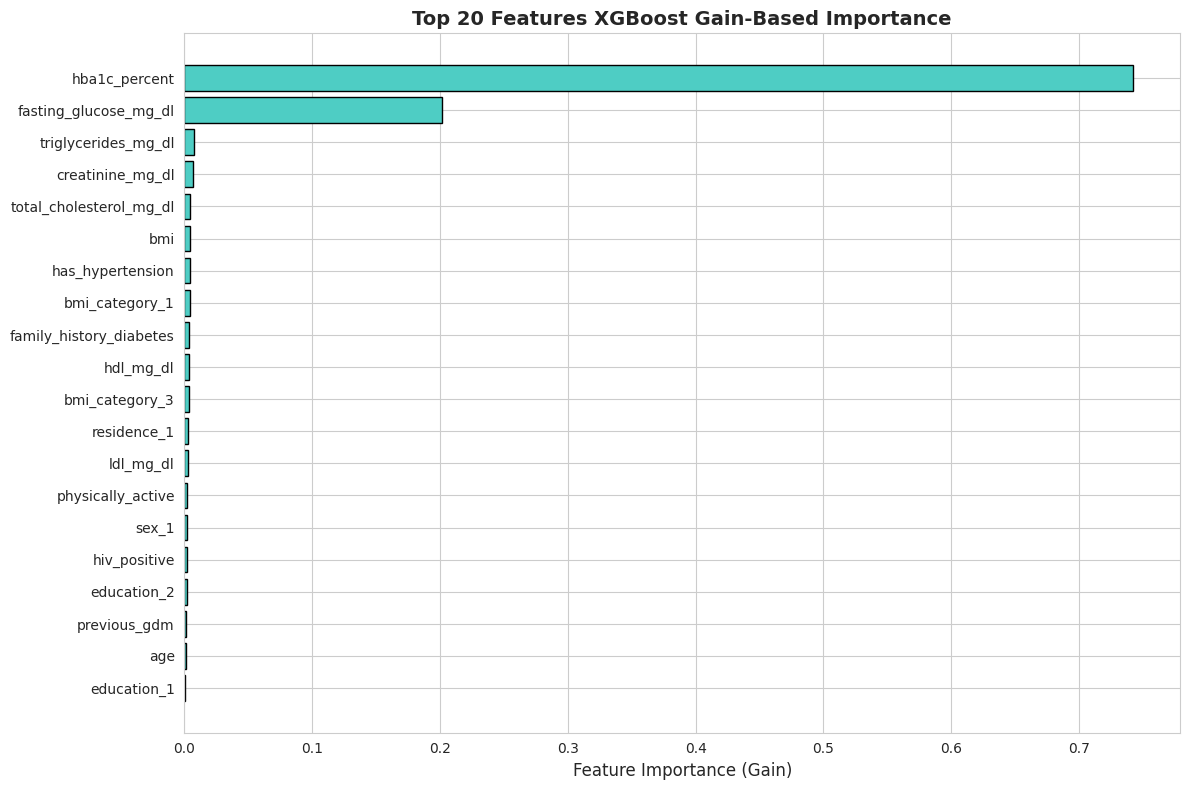

In [40]:
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(12, 8))
plt.barh(range(len(importance_df)), importance_df['Importance'].values[::-1],
         color='#4ECDC4', edgecolor='black')
plt.yticks(range(len(importance_df)), importance_df['Feature'].values[::-1], fontsize=10)
plt.xlabel('Feature Importance (Gain)', fontsize=12)
plt.title('Top 20 Features XGBoost Gain-Based Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **13. SHAP KernelExplainer (Deep Learning Model)**

In [41]:
bg_size = 100
exp_size = 50
X_background = X_train_smote[np.random.choice(X_train_smote.shape[0], bg_size, replace=False)]
X_explain = X_test[:exp_size]
explainer_dl = shap.KernelExplainer(dl_predict_proba, X_background)
shap_values_dl = explainer_dl.shap_values(X_explain, nsamples=50)
print(f"SHAP values computed: {np.array(shap_values_dl).shape}")

  0%|          | 0/50 [00:00<?, ?it/s]

SHAP values computed: (50, 25, 3)


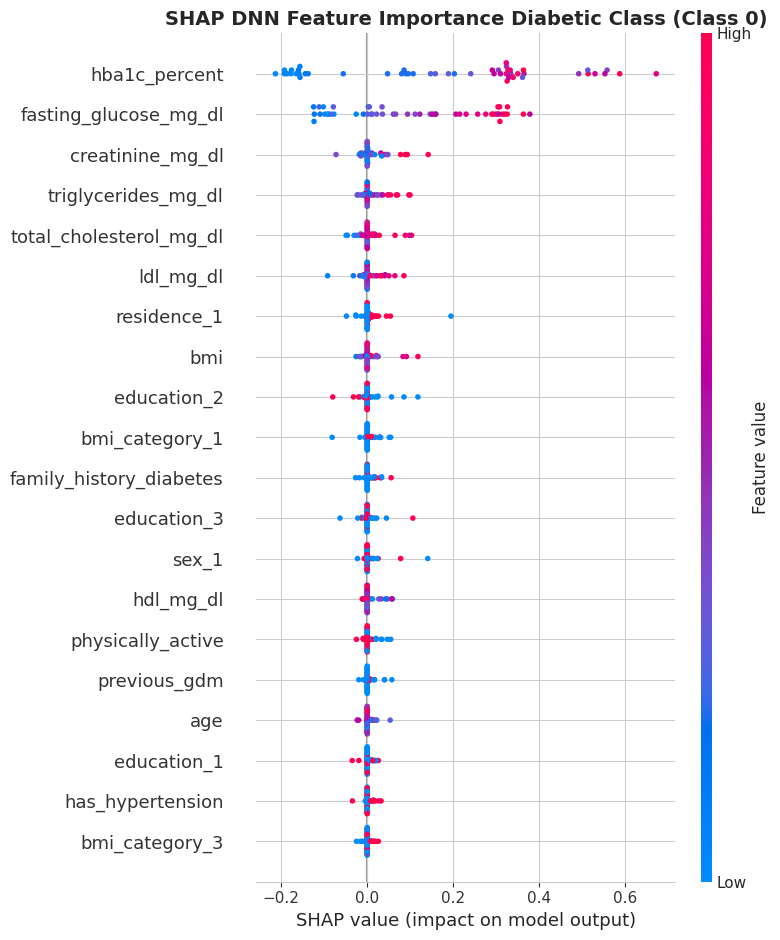

In [42]:
# SHAP DL summary (index 0 = Diabetic)
shap_values_dl = _as_shap_array(shap_values_dl, X_explain.shape[0], X_explain.shape[1])
shap_dl_diabetic = shap_values_dl[:, :, 0]

plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_dl_diabetic, X_explain,
    feature_names=all_feature_names, max_display=20, show=False
)
plt.title(f'SHAP {best_model_name} Feature Importance Diabetic Class (Class 0)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **14. Final Summary**

In [43]:
print(f"""
DATASET
   Source:      Dataset.csv (African Diabetes Dataset)
   Records:     10,000
   Features:    {len(feature_cols)} used after screening
   Target:      diabetes_status (3-class)

PREPROCESSING
   Removed {len(outcome_cols)} outcome columns (data leakage prevention)
   Dropped {len(drop_pregnancy_cols)} pregnancy columns (structural missing)
   SMOTENC applied to the training partition only

DEEP-LEARNING RESULTS
   ANN:  Accuracy = {metrics_ann[0]:.4f}, F1 = {metrics_ann[3]:.4f}, AUC = {metrics_ann[4]:.4f}
   DNN:  Accuracy = {metrics_dnn[0]:.4f}, F1 = {metrics_dnn[3]:.4f}, AUC = {metrics_dnn[4]:.4f}

COMPARISON MODEL
   XGBoost: Accuracy = {xgb_acc:.4f}, F1 = {xgb_f1:.4f}

BEST DEEP-LEARNING MODEL: {best_model_name}
   F1-Score: {max(metrics_ann[3], metrics_dnn[3]):.4f}
   AUC-ROC:  {max(metrics_ann[4], metrics_dnn[4]):.4f}

NOTE
   DNN is selected as the best deep-learning model by weighted F1.
   XGBoost is the strongest overall reported classifier and is retained as the
   non-neural comparison model.
""")



DATASET
   Source:      Dataset.csv (African Diabetes Dataset)
   Records:     10,000
   Features:    21 used after screening
   Target:      diabetes_status (3-class)
PREPROCESSING
   Removed 11 outcome columns (data leakage prevention)
   Dropped 6 pregnancy columns (structural missing)
   SMOTENC applied: All classes balanced
RESULTS
   ANN:  Accuracy = 0.9873, F1 = 0.9873, AUC = 0.9996
   DNN:  Accuracy = 0.9887, F1 = 0.9887, AUC = 0.9996
   XGBoost: Accuracy = 0.9973, F1 = 0.9973
BEST MODEL: DNN
   F1-Score: 0.9887
   AUC-ROC:  0.9996



## **15. Save Models and Preprocessors**

In [44]:
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(le_target, 'label_encoder.pkl')
joblib.dump(xgb_model, 'xgb_model.pkl')
best_model.save('best_dl_model.keras')
ann_model.save('ann_model.keras')
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(all_feature_names, f)
joblib.dump(smote, 'smote.pkl')
for f in sorted(os.listdir('.')):
    if f.endswith(('.pkl', '.keras')):
        print(f"  {f} ({os.path.getsize(f)/1024:.1f} KB)")

  ann_model.keras (667.2 KB)
  best_dl_model.keras (3104.8 KB)
  feature_names.pkl (0.4 KB)
  label_encoder.pkl (0.5 KB)
  preprocessor.pkl (4.6 KB)
  smote.pkl (237.9 KB)
  xgb_model.pkl (646.2 KB)


## **16. Prediction Function**

In [45]:
def predict_diabetes_risk(patient_data_dict, model_type="dnn", explain=True):
    """
    Reusable prediction API for the research prototype.

    model_type: "dnn" for the selected deep-learning model or
                "xgboost" for the non-neural comparison model.
    """
    if model_type not in {"dnn", "xgboost"}:
        raise ValueError("model_type must be 'dnn' or 'xgboost'.")

    required = list(X.columns)
    missing = [col for col in required if col not in patient_data_dict]
    if missing:
        raise ValueError("Missing required patient features: " + ", ".join(missing))

    patient_df = pd.DataFrame([{col: patient_data_dict[col] for col in required}])

    for col in num_cols:
        patient_df[col] = pd.to_numeric(
            patient_df[col], errors="coerce"
        ).fillna(numeric_fill_values[col])

    for col in cat_cols:
        mapping = {label: idx for idx, label in enumerate(cat_encoders[col].classes_)}
        patient_df[col] = (
            patient_df[col].astype(str).map(mapping).fillna(-1).astype(int)
        )

    for col in bool_cols:
        patient_df[col] = patient_df[col].astype("boolean").fillna(False).astype(int)

    patient_processed = preprocessor.transform(patient_df)

    if np.isnan(patient_processed).any():
        raise ValueError("Preprocessed patient input contains NaN values.")

    if model_type == "dnn":
        selected_model = best_model
        probabilities = selected_model.predict(patient_processed, verbose=0)[0]
    else:
        selected_model = xgb_model
        probabilities = selected_model.predict_proba(patient_processed)[0]

    probabilities = np.asarray(probabilities, dtype=float)
    probabilities = probabilities / probabilities.sum()
    pred_class = int(np.argmax(probabilities))

    result = {
        "model": "DNN" if model_type == "dnn" else "XGBoost",
        "prediction": le_target.classes_[pred_class],
        "predicted_probability": float(probabilities[pred_class]),
        "probabilities": {
            cls: float(prob)
            for cls, prob in zip(le_target.classes_, probabilities)
        }
    }

    if explain:
        if model_type == "dnn":
            lime_exp = lime_explainer.explain_instance(
                data_row=patient_processed[0],
                predict_fn=dl_predict_proba,
                num_features=10,
                top_labels=len(le_target.classes_)
            )
            result["explanation_method"] = "LIME"
            result["explanation"] = lime_exp.as_list(label=pred_class)
        else:
            explainer = shap.TreeExplainer(xgb_model)
            raw_values = explainer.shap_values(patient_processed)
            shap_values = _as_shap_array(
                raw_values, patient_processed.shape[0], patient_processed.shape[1]
            )
            result["explanation_method"] = "SHAP"
            explanation = [
                (feature, float(value))
                for feature, value in zip(
                    all_feature_names, shap_values[0, :, pred_class]
                )
            ]
            result["explanation"] = sorted(
                explanation, key=lambda item: abs(item[1]), reverse=True
            )[:10]

    return result


# Demonstration using a record already present in the selected dataset.
sample_patient = X.iloc[0].to_dict()
dnn_result = predict_diabetes_risk(sample_patient, model_type="dnn", explain=True)

print("=== RESEARCH PROTOTYPE PREDICTION ===")
print(f"Model:                 {dnn_result['model']}")
print(f"Predicted class:       {dnn_result['prediction']}")
print(f"Predicted probability: {dnn_result['predicted_probability']:.2%}")
print("\nClass probabilities:")
for cls, prob in dnn_result["probabilities"].items():
    print(f"  {cls:<15}: {prob:.4f}")

print(f"\nExplanation method: {dnn_result['explanation_method']}")
for feature, contribution in dnn_result["explanation"]:
    print(f"  {feature:<45} {contribution:+.4f}")

print("\nResearch prototype only — not a medical diagnosis.")


Prediction : Diabetic
Confidence : 100.00%
Diabetic       : 1.0000
Normal         : 0.0000
Prediabetes    : 0.0000
fasting_glucose_mg_dl > 0.32                  +0.5480   (INCREASES prediction)
pcos <= 0.00                                  +0.1363   (INCREASES prediction)
family_history_diabetes <= 0.00               -0.1067   (DECREASES prediction)
triglycerides_mg_dl > 0.56                    +0.1048   (INCREASES prediction)
total_cholesterol_mg_dl > 0.62                +0.0779   (INCREASES prediction)
hdl_mg_dl <= -0.69                            +0.0699   (INCREASES prediction)
bmi_category_1 <= 0.00                        -0.0505   (DECREASES prediction)
creatinine_mg_dl <= -0.62                     -0.0495   (DECREASES prediction)
0.00 < physically_active <= 1.00              -0.0477   (DECREASES prediction)
previous_macrosomia <= 0.00                   +0.0412   (INCREASES prediction)


## **17. Unified Model Evaluation**

This section provides a single comparison table for the two deep-learning models and the XGBoost reference model. The purpose is to evaluate the deep-learning objective without assuming that deep learning must outperform a tree-based method.

In [ ]:
# Unified comparison across all trained models
xgb_proba = xgb_model.predict_proba(X_test)

xgb_precision = precision_score(y_test, xgb_pred, average="weighted")
xgb_recall = recall_score(y_test, xgb_pred, average="weighted")
xgb_auc = roc_auc_score(
    y_test_cat, xgb_proba, multi_class="ovr", average="weighted"
)

comparison_all = pd.DataFrame([
    {"Model": "ANN", "Accuracy": metrics_ann[0], "Precision": metrics_ann[1],
     "Recall": metrics_ann[2], "F1": metrics_ann[3], "ROC-AUC": metrics_ann[4]},
    {"Model": "DNN", "Accuracy": metrics_dnn[0], "Precision": metrics_dnn[1],
     "Recall": metrics_dnn[2], "F1": metrics_dnn[3], "ROC-AUC": metrics_dnn[4]},
    {"Model": "XGBoost", "Accuracy": xgb_acc, "Precision": xgb_precision,
     "Recall": xgb_recall, "F1": xgb_f1, "ROC-AUC": xgb_auc}
]).round(4)

display(comparison_all)

print(f"Best deep-learning model by weighted F1: {best_model_name} "
      f"({max(metrics_ann[3], metrics_dnn[3]):.4f})")
print(f"Best overall model by weighted F1: "
      f"{comparison_all.loc[comparison_all['F1'].idxmax(), 'Model']} "
      f"({comparison_all['F1'].max():.4f})")


## **18. Artefact Validation and Automated Testing**

The following tests verify that the prediction component is internally consistent, returns valid class probabilities, preserves the expected feature dimension and can produce explanations. This provides direct evidence of implementation and testing rather than relying only on model-performance metrics.

In [ ]:
def run_artifact_tests():
    sample = X.iloc[0].to_dict()

    dnn = predict_diabetes_risk(sample, model_type="dnn", explain=True)
    assert dnn["prediction"] in list(le_target.classes_)
    assert set(dnn["probabilities"]) == set(le_target.classes_)
    assert np.isclose(sum(dnn["probabilities"].values()), 1.0, atol=1e-6)
    assert dnn["explanation_method"] == "LIME"
    assert len(dnn["explanation"]) > 0

    xgb_result = predict_diabetes_risk(sample, model_type="xgboost", explain=True)
    assert xgb_result["prediction"] in list(le_target.classes_)
    assert np.isclose(sum(xgb_result["probabilities"].values()), 1.0, atol=1e-6)
    assert xgb_result["explanation_method"] == "SHAP"
    assert len(xgb_result["explanation"]) > 0

    transformed = preprocessor.transform(X_test_raw.iloc[[0]])
    assert transformed.shape[1] == len(all_feature_names)
    assert not np.isnan(transformed).any()

    expected_files = [
        "preprocessor.pkl", "label_encoder.pkl", "xgb_model.pkl",
        "best_dl_model.keras", "ann_model.keras",
        "feature_names.pkl", "smote.pkl"
    ]
    missing_files = [f for f in expected_files if not os.path.exists(f)]

    print("=== ARTEFACT VALIDATION ===")
    print("✓ DNN prediction and probability validation passed")
    print("✓ XGBoost prediction and probability validation passed")
    print("✓ LIME local explanation generated")
    print("✓ SHAP local explanation generated")
    print("✓ Preprocessing feature dimension is consistent")
    if missing_files:
        print("⚠ Missing saved artefacts:", missing_files)
    else:
        print("✓ All expected saved model/preprocessing artefacts found")

    return {
        "dnn_test": "passed",
        "xgboost_test": "passed",
        "preprocessing_test": "passed",
        "missing_saved_files": missing_files
    }

artifact_test_results = run_artifact_tests()


## **19. Reproducible Demonstration**

Three records are evaluated using the reusable prediction API. This demonstrates that the artefact is not limited to one hard-coded example and that the same preprocessing and model pipeline can be applied repeatedly.

In [ ]:
demo_indices = [0, len(X)//2, len(X)-1]
demo_rows = []

for idx in demo_indices:
    result = predict_diabetes_risk(
        X.iloc[idx].to_dict(),
        model_type="dnn",
        explain=False
    )
    demo_rows.append({
        "Dataset index": idx,
        "Predicted class": result["prediction"],
        "Predicted probability": round(result["predicted_probability"], 4),
        "Diabetic": round(result["probabilities"]["Diabetic"], 4),
        "Normal": round(result["probabilities"]["Normal"], 4),
        "Prediabetes": round(result["probabilities"]["Prediabetes"], 4)
    })

demo_df = pd.DataFrame(demo_rows)
display(demo_df)


## **20. Artefact Scope, Safety and Reproducibility**

The artefact is a research prototype rather than a clinical diagnostic application. Its main contribution is the reproducible integration of preprocessing, three-class prediction, model comparison and local/global explanation. The prediction API distinguishes between the selected deep-learning model and the XGBoost comparator and uses model-appropriate probability and explanation methods.

The predicted probability is a model output and should not be interpreted as a calibrated clinical risk unless calibration and external validation have been demonstrated. Explanations describe model behaviour rather than causal relationships. Any future deployment would require independent validation, calibration, subgroup evaluation, security controls, clinical governance and user testing.

### **Important methodological check before final submission**

The report states that numerical imputation is based on the training split. In the current notebook version, the original cached run performs the initial imputation before the train/validation/test split. This should be corrected and the models rerun before the final submission so that imputation statistics are learned from the training partition only. Do not report the cached performance numbers as the final corrected results until the corrected pipeline has been executed.